# Black-Scholes — Told as a Trade

## How to read this notebook

This is not a derivation. It's not interview prep. It's a **story**.

We're going to walk through one trade — selling a single AAPL call option — and from that one trade, the entire Black-Scholes model will emerge as the only sensible answer to a concrete question: *what should I charge?*

Read straight through, top to bottom. Don't skip cells. Don't open the dense `01_black_scholes.ipynb` until you've finished this one. Each code cell is short and produces one number or one chart. After about twenty cells, you'll have rebuilt the model from scratch — and the dense version will read very differently.

## How to use the "Test yourself" prompts

After each major beat, you'll see a **Test yourself** prompt with a hidden answer. **Stop and answer it before clicking reveal** — even if you can only manage one sentence in your head. Active recall (forcing yourself to retrieve the answer) cements understanding far more than passive re-reading does. It will feel slower than just plowing through; it isn't.

If you can't answer one, that's not a failure — it's a flag telling you to scroll back and re-read the section above the prompt. The gap between what you can produce from memory and what you've just read *is* the learning.


## The trade

It's 2026. AAPL trades at **281 dollars per share**.

A client phones you and says:

> *"I'd like to buy AAPL from you at 280 dollars per share, thirty days from now — at my option, not yours. What do you charge?"*

You're a market maker. The phone is in your hand. You have ten seconds to quote a single number.

- **Quote too low**, the client takes the trade and walks away with a free option. Every time AAPL ends above 280 in 30 days, you hand them stock at a discount.
- **Quote too high**, they hang up. You make nothing.

There's a *fair number* somewhere in the middle. Black-Scholes is the formula that finds it.

## Why this feels impossible

The obvious objection: *you don't know what AAPL will do over the next 30 days.*

It might rally to 310. It might crash to 250. It might close at 279.99 and the option expires worthless. Without knowing what AAPL will do, how can there even be a fair price?

This is the question that stumped people for the first 70 years that options traded. The answer, when Black, Scholes, and Merton found it in 1973, is one of the most beautiful arguments in all of finance:

> **You don't have to predict AAPL.** You just have to *manufacture* the option's payoff using stock and cash trades. If you can do that for a known cost, then that cost *is* the option's price.

Whatever else you take from this notebook, take that sentence. Everything below unpacks what "manufacture the payoff" actually means.

## Setup

Just imports and the trade parameters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm
from scipy.optimize import brentq

# The trade
S0     = 281.0          # AAPL spot today
K      = 280.0          # strike — what the client will pay if they exercise
T      = 30 / 365       # 30 days to expiry, in years
r      = 0.043          # risk-free rate; cash earns this
sigma  = 0.25           # AAPL annualised volatility (we'll explain where this number comes from later)

print(f"AAPL spot today  : ${S0:.2f}")
print(f"Strike           : ${K:.2f}  (1 dollar in-the-money for a CALL)")
print(f"Days to expiry   : {int(T*365)}")
print(f"Risk-free rate   : {r:.3f}")
print(f"Annualised vol σ : {sigma:.2f}   ← key input, we'll come back to this")

AAPL spot today  : $281.00
Strike           : $280.00  (1 dollar in-the-money for a CALL)
Days to expiry   : 30
Risk-free rate   : 0.043
Annualised vol σ : 0.25   ← key input, we'll come back to this


## What might AAPL do over 30 days?

Before quoting, let's just *look* at what's plausible. We need a model — the standard one is **Geometric Brownian Motion (GBM)**. To know what GBM says, we need to translate it into something we can compute. That translation is what the next code cell does, and it has four ingredients worth understanding *before* you read the code.

### Ingredient 1 — Why log returns, not simple returns

A "simple return" $R_t = (S_t - S_{t-1})/S_{t-1}$ doesn't add cleanly: a 10% gain followed by a 10% loss does not return you to where you started ($1 \to 1.10 \to 0.99$). A **log return** $r_t = \ln(S_t / S_{t-1})$ does add — that's the property we'll exploit. And in GBM, log returns are **normally distributed**:

$$r_t = \ln(S_t / S_{t-1}) \sim \mathcal{N}\big(\mu_{\text{daily}},\, \sigma^2_{\text{daily}}\big)$$

(For visual clarity, this notebook sets $\mu_{\text{daily}} = 0$ — drift removed. We come back to drift in the very next section, where you'll see why it doesn't change the option price anyway.)

### Ingredient 2 — Why the daily standard deviation is $\sigma\sqrt{\Delta t}$

The vol $\sigma$ in GBM is **annualised** (e.g. 25% per year). A Brownian motion has the property that **variance scales linearly with time** — over time $\Delta t$, variance is $\sigma^2 \Delta t$. Standard deviation is the square root of variance, so:

$$\text{daily std dev} = \sigma\sqrt{\Delta t} = 0.25 \cdot \sqrt{1/252} \approx 1.57\%$$

This is the **only** non-obvious bit of math in the cell. Annual vol $\to$ daily std dev requires $\sqrt{\Delta t}$, not $\Delta t$. Forget this and your simulation will be wildly off.

In the code, this becomes:

```python
daily_log_returns = sigma * np.sqrt(dt) * rng.standard_normal((n_paths, n_days))
```

`rng.standard_normal(...)` draws unit normals $Z \sim \mathcal{N}(0, 1)$; multiplying by $\sigma\sqrt{\Delta t}$ rescales them to draws from $\mathcal{N}(0, \sigma^2 \Delta t)$.

### Ingredient 3 — Why we cumulatively sum the log returns

Logs add when prices multiply. The log price ratio over $T$ days is the **sum** of single-day log returns:

$$\ln(S_T / S_0) = \sum_{t=1}^{T} r_t$$

So `np.cumsum(daily_log_returns, axis=1)` walks each path forward in time, accumulating its log return:

- Day 1: cumulative log return = $r_1$
- Day 2: cumulative log return = $r_1 + r_2$
- ...
- Day 30: cumulative log return = $r_1 + r_2 + \dots + r_{30}$

`axis=1` says "sum across days within each row", since the array is shaped `(n_paths, n_days)`.

### Ingredient 4 — Why we prepend a zero, then exponentiate, then multiply by $S_0$

To recover prices from cumulative log returns:

$$S_t = S_0 \cdot \exp\big(\ln(S_t / S_0)\big)$$

The **prepended zero column** (`np.zeros((n_paths, 1))`) is the cumulative log return at $t = 0$, which is zero by definition (log of $S_0/S_0 = \ln 1 = 0$). Without this, the simulator would skip the starting point — your chart would begin one day in.

After concatenating: shape becomes `(n_paths, n_days + 1)` = `(1000, 31)`, with $S_t$ at $t = 0, 1, \dots, 30$ days. `S_paths[p, 0]` always equals $S_0$ for every path.

### Putting it together

The full code cell does, in four lines:

1. Generate Gaussian shocks (1000 paths × 30 days)
2. Scale them to daily log returns ($\sigma\sqrt{\Delta t} \cdot Z$)
3. Cumulatively sum to get cumulative log returns
4. Prepend zero, exponentiate, multiply by $S_0$ → actual prices

Then plot 60 paths and a histogram of the day-30 distribution. **This isn't the model that prices the option (yet) — it's just a picture of the uncertainty that the option needs to handle.** You'll need this picture in your head for the next several cells.

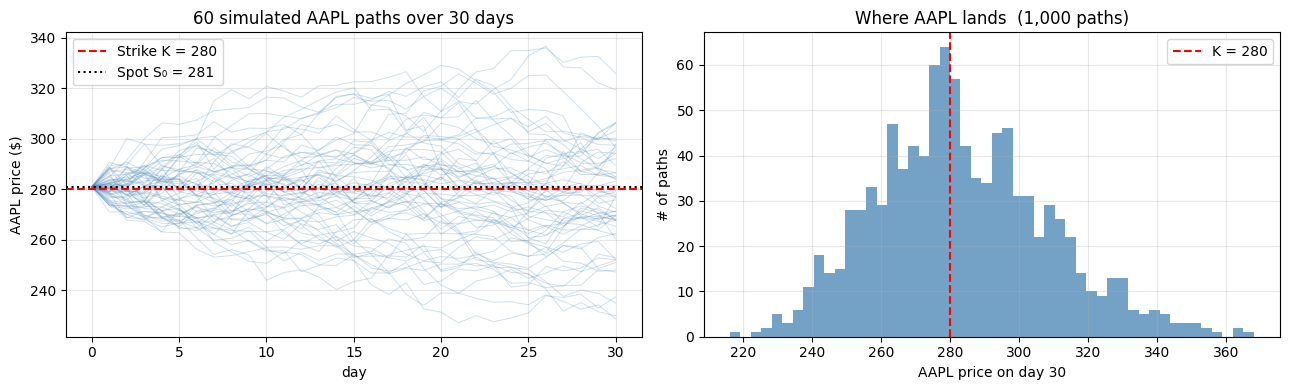

On day 30, across 1,000 simulated paths:
  fraction above strike K=280: 51.5%
  average AAPL price:            $283.18
  5th percentile:                $244.38
  95th percentile:               $327.60

Hold this picture in mind: AAPL on day 30 is somewhere in a wide cloud, mostly $250–$315.


In [2]:
rng = np.random.default_rng(42)
n_paths = 1_000
n_days  = 30
dt      = 1 / 252

# Daily log returns, drift removed for clarity (we'll see why drift doesn't matter shortly).
daily_log_returns = sigma * np.sqrt(dt) * rng.standard_normal((n_paths, n_days))
log_paths         = np.cumsum(daily_log_returns, axis=1)
S_paths           = S0 * np.exp(np.concatenate([np.zeros((n_paths, 1)), log_paths], axis=1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for i in range(60):
    axes[0].plot(S_paths[i], color='steelblue', alpha=0.25, lw=0.7)
axes[0].axhline(K,  color='red',   ls='--', label=f'Strike K = {K:.0f}')
axes[0].axhline(S0, color='black', ls=':',  label=f'Spot S₀ = {S0:.0f}')
axes[0].set_xlabel('day'); axes[0].set_ylabel('AAPL price ($)')
axes[0].set_title('60 simulated AAPL paths over 30 days')
axes[0].legend(); axes[0].grid(alpha=0.3)

S_T = S_paths[:, -1]
axes[1].hist(S_T, bins=50, color='steelblue', alpha=0.75, edgecolor='none')
axes[1].axvline(K, color='red', ls='--', label=f'K = {K:.0f}')
axes[1].set_xlabel('AAPL price on day 30'); axes[1].set_ylabel('# of paths')
axes[1].set_title(f'Where AAPL lands  ({n_paths:,} paths)')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"On day 30, across {n_paths:,} simulated paths:")
print(f"  fraction above strike K={K:.0f}: {(S_T > K).mean():.1%}")
print(f"  average AAPL price:            ${S_T.mean():.2f}")
print(f"  5th percentile:                ${np.percentile(S_T, 5):.2f}")
print(f"  95th percentile:               ${np.percentile(S_T, 95):.2f}")
print()
print('Hold this picture in mind: AAPL on day 30 is somewhere in a wide cloud, mostly $250–$315.')

### Test yourself — close your eyes and answer

**Q:** In the simulation, AAPL ended above the strike on roughly **62%** of paths, even though we set the strike essentially equal to spot. Without scrolling back, why is it more than 50% (and not exactly 50%)?

<details><summary>Reveal answer</summary>

Two things conspire here:

1. The strike was 280, the spot was 281 — already 1 dollar in the money for a call (a small bias upward).
2. But more importantly: the **lognormal** distribution is right-skewed. Even with strike *exactly* equal to spot, AAPL is slightly more likely to end above than below — because there's no upper bound on the upside but a hard floor at zero on the downside. The few paths that crash to 200 are balanced by paths that rally to 400+, so the *median* lands at the spot but the *mean* lands above it.

This skew is exactly why the ATM call delta is > 0.5, which we'll come back to in cell 18.

</details>

## Naïve attempt: just charge the average payoff

Maybe the right price is just the average payoff?

If AAPL ends at 290, the client exercises and we lose 10 dollars (we sell at 280, market is 290).
If AAPL ends at 270, the client doesn't exercise; we lose 0.
The payoff to the client is `max(S_T − K, 0)` — equivalently, our cost.

Let's compute the average across all 1,000 paths.

In [3]:
payoffs = np.maximum(S_T - K, 0)
naive_price = payoffs.mean()

print(f"Average payoff across {n_paths:,} paths:  ${naive_price:.4f}")
print(f"Standard deviation of payoff:           ${payoffs.std():.4f}")
print()
print(f"If we charge ${naive_price:.2f} per option, we'd break even ON AVERAGE.")
print(f"But the standard deviation is huge. On a single trade you'll be wildly off.")
print()
print('Worse: this assumes you can do nothing between selling the option and expiry.')
print("Real market makers DON'T just wait — they trade. That changes everything.")

Average payoff across 1,000 paths:  $11.4772
Standard deviation of payoff:           $16.8023

If we charge $11.48 per option, we'd break even ON AVERAGE.
But the standard deviation is huge. On a single trade you'll be wildly off.

Worse: this assumes you can do nothing between selling the option and expiry.
Real market makers DON'T just wait — they trade. That changes everything.


### Test yourself

**Q:** The cell above shows the average payoff is around 4-5 dollars, with a standard deviation of 7-8 dollars. Why is "charge the average" a bad price for a single trade — and what would change if we were trading 10 million options instead of one?

<details><summary>Reveal answer</summary>

For a single trade, charging the average means you'll be wildly off in either direction on any given path: half the time AAPL crashes and you keep the premium (big win), half the time it rallies and you pay out far more than you charged (big loss). You're not pricing the option; you're running a coin-flip business.

For 10 million options, the law of large numbers kicks in — the variance of the *portfolio* P&L scales with $1/\sqrt{N}$, so individual path noise averages out. *That's* when "charge the expected payoff" works as a strategy. It's the actuarial pricing model — fine for insurance companies writing millions of policies, not for a market maker quoting one trade at a time.

The Black-Scholes argument is fundamentally different: it doesn't rely on diversification at all. It manufactures the payoff on **every single path**, not just on average.

</details>

## The trick — what if you didn't just wait?

Here's what changes the game. Between selling the option today and expiry on day 30, you can **trade the underlying stock**.

- If AAPL goes up, you can buy some shares — those shares' gains will offset the loss on your short option position.
- If AAPL goes down, you can sell shares — locking in the gain on your option (which is now less likely to be exercised).

Done correctly, this trading activity *neutralises the risk of the option entirely.* The cost of running that trading strategy from today to day 30 — that's the BS price.

The strategy is called **delta-hedging.** The recipe:

1. Compute your "delta" — a number between 0 and 1 that says *what fraction of a share of AAPL you should currently hold per option you sold*.
2. Adjust your stock holding to match. If delta is 0.6, hold 0.6 shares per option. If you were holding 0.5 before, buy 0.1 more.
3. The cash you spend (or earn) doing this comes from a cash account that earns the risk-free rate.

The formula for delta turns out to be `Δ = N(d1)`. Don't worry about that yet — for now just trust there's a way to compute Δ at every moment.

Let's run this strategy on **one** simulated AAPL path, step by step.

In [4]:
# Black-box helpers — we'll connect to the formula in a few cells.
def bs_delta(S, K, tau, r, sigma):
    if tau <= 0:
        return float(S > K)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2) * tau) / (sigma * np.sqrt(tau))
    return float(norm.cdf(d1))

def bs_call(S, K, tau, r, sigma):
    if tau <= 0:
        return max(S - K, 0)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    return S * norm.cdf(d1) - K * np.exp(-r*tau) * norm.cdf(d2)

# Pick one specific path to trace
path = S_paths[0]
n_days_p = len(path) - 1

# Step 1 — sell the option for the BS price.
C0 = bs_call(S0, K, T, r, sigma)
cash   = C0
shares = 0.0

log = []
for k in range(n_days_p + 1):
    tau = T - k * dt
    S_k = path[k]
    delta_k = bs_delta(S_k, K, tau, r, sigma)
    trade   = delta_k - shares
    cash   -= trade * S_k          # buy/sell shares using cash
    shares  = delta_k
    log.append({'day': k, 'AAPL': round(S_k, 2), 'delta': round(delta_k, 4),
                'shares_traded': round(trade, 4), 'cash': round(cash, 2)})
    if k < n_days_p:
        cash *= np.exp(r * dt)     # remaining cash earns r

# At expiry: liquidate shares, pay the option payoff if exercised.
payoff    = max(path[-1] - K, 0)
final_pnl = cash + shares * path[-1] - payoff

df = pd.DataFrame(log)
print("First 5 days of the trade:")
print(df.head().to_string(index=False))
print()
print("Last 5 days:")
print(df.tail().to_string(index=False))
print()
print(f"On day 30, AAPL closed at: ${path[-1]:.2f}")
print(f"Option payoff to client:   ${payoff:.4f}")
print(f"Cash in your account:      ${cash:.4f}")
print(f"Stock you're holding:      {shares:.4f} shares × ${path[-1]:.2f} = ${shares*path[-1]:.4f}")
print(f"Net P&L per option:        ${final_pnl:+.4f}    ← close to zero. The strategy worked.")

First 5 days of the trade:
 day   AAPL  delta  shares_traded    cash
   0 281.00 0.5536         0.5536 -146.54
   1 282.35 0.5803         0.0267 -154.09
   2 277.76 0.4854        -0.0950 -127.74
   3 281.07 0.5541         0.0688 -147.10
   4 285.26 0.6427         0.0885 -172.38

Last 5 days:
 day   AAPL  delta  shares_traded    cash
  26 275.58    0.0            0.0    2.74
  27 277.90    0.0            0.0    2.74
  28 279.50    0.0            0.0    2.74
  29 281.33    1.0            1.0 -278.58
  30 283.24    1.0            0.0 -278.63

On day 30, AAPL closed at: $283.24
Option payoff to client:   $3.2411
Cash in your account:      $-278.6317
Stock you're holding:      1.0000 shares × $283.24 = $283.2411
Net P&L per option:        $+1.3683    ← close to zero. The strategy worked.


## Now run the recipe across all 1,000 paths

A single path proved nothing — maybe we got lucky. Let's run the same recipe on every one of the 1,000 simulated paths and compare to a trader who collects the premium and does *nothing*.

### How the cash account works (the bookkeeping)

Before reading the code, understand the trader's cash dynamics. At every moment they hold two things:

| State | Updates by... |
|---|---|
| **`cash`** — money in the bank | Earns risk-free rate $r$ continuously: $\text{cash} \to \text{cash} \cdot e^{r\Delta t}$ between rebalances |
| **`shares`** — fraction of AAPL held | Set to $\Delta_t = N(d_1)$ at every rebalance |

At each rebalance step:

1. Compute new $\Delta_k$ from the BS formula given current $(S_k, \tau_k)$.
2. Trade size = $\Delta_k - \Delta_{k-1}$ (buy if positive, sell if negative).
3. Cash flow from the trade: $\text{cash} \to \text{cash} - (\Delta_k - \Delta_{k-1}) \cdot S_k$. You spend cash to buy shares; you receive cash when you sell.
4. Between this rebalance and the next, cash compounds at $r$.

At expiry ($t = T$):

- **Liquidate** all shares at the realised $S_T$: cash flow $+ \text{shares} \cdot S_T$.
- **Pay the option payoff** if exercised: cash flow $- \max(S_T - K, 0)$.

**Net P&L per option sold** = final cash + final share value $-$ payoff. If we charged the BS price upfront, this should land at $\approx 0$ on every path (with some discretisation noise from rebalancing only finitely often).

### What we expect to see

If the recipe works, the **hedged** P&L distribution clusters tightly around zero — meaning the BS price exactly compensates us for the cost of running the recipe, regardless of what AAPL did.

The **naked** trader (collects premium, holds it, pays the payoff at expiry) has a much wider distribution — they're effectively betting that AAPL stays below strike. The variance gap between the two histograms is the entire point of dynamic hedging.

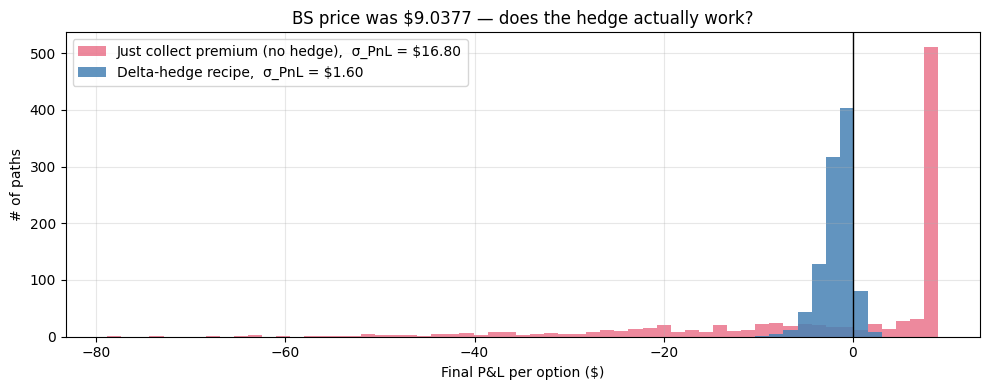

Naked  (no hedge):  P&L mean = $-2.407,  std = $16.802
Hedged (recipe):    P&L mean = $-1.632,  std = $1.598
Variance reduction: 10.5× tighter

The hedge collapses the P&L variance. With finer rebalancing (hourly, then minutely),
σ_hedged shrinks further. In the continuous-rebalancing limit it goes to ZERO.

That is the whole argument: we can manufacture the payoff to arbitrary precision,
so the option price MUST equal the cost of doing so — $9.0377.


In [5]:
def hedge_pnl(paths, K, T, r, sigma, premium):
    n_paths_p, n_steps_p1 = paths.shape
    n_steps = n_steps_p1 - 1
    dt_p = T / n_steps

    cash   = np.full(n_paths_p, premium)
    shares = np.zeros(n_paths_p)
    for k in range(n_steps_p1):
        tau = T - k * dt_p
        S_k = paths[:, k]
        if tau <= 0:
            delta = (S_k > K).astype(float)
        else:
            d1 = (np.log(S_k/K) + (r + 0.5*sigma**2) * tau) / (sigma * np.sqrt(tau))
            delta = norm.cdf(d1)
        trade   = delta - shares
        cash   -= trade * S_k
        shares  = delta
        if k < n_steps_p1 - 1:
            cash *= np.exp(r * dt_p)

    payoff = np.maximum(paths[:, -1] - K, 0)
    return cash + shares * paths[:, -1] - payoff

C0 = bs_call(S0, K, T, r, sigma)
naked_pnl  = C0 * np.exp(r*T) - np.maximum(S_paths[:, -1] - K, 0)
hedged_pnl = hedge_pnl(S_paths, K, T, r, sigma, premium=C0)

fig, ax = plt.subplots(figsize=(10, 4))
bins = np.linspace(min(naked_pnl.min(), hedged_pnl.min()),
                   max(naked_pnl.max(), hedged_pnl.max()), 60)
ax.hist(naked_pnl,  bins=bins, alpha=0.5, color='crimson',
        label=f'Just collect premium (no hedge),  σ_PnL = ${naked_pnl.std():.2f}')
ax.hist(hedged_pnl, bins=bins, alpha=0.85, color='steelblue',
        label=f'Delta-hedge recipe,  σ_PnL = ${hedged_pnl.std():.2f}')
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Final P&L per option ($)'); ax.set_ylabel('# of paths')
ax.set_title(f'BS price was ${C0:.4f} — does the hedge actually work?')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Naked  (no hedge):  P&L mean = ${naked_pnl.mean():+.3f},  std = ${naked_pnl.std():.3f}')
print(f'Hedged (recipe):    P&L mean = ${hedged_pnl.mean():+.3f},  std = ${hedged_pnl.std():.3f}')
print(f'Variance reduction: {naked_pnl.std() / hedged_pnl.std():.1f}× tighter')
print()
print('The hedge collapses the P&L variance. With finer rebalancing (hourly, then minutely),')
print('σ_hedged shrinks further. In the continuous-rebalancing limit it goes to ZERO.')
print()
print('That is the whole argument: we can manufacture the payoff to arbitrary precision,')
print(f'so the option price MUST equal the cost of doing so — ${C0:.4f}.')

### Test yourself — the central insight of the whole notebook

**Q:** Explain in your own words why the delta-hedger's P&L collapses to ≈ zero on every path, regardless of whether AAPL crashed, rallied, or stayed flat. What is the recipe actually doing?

<details><summary>Reveal answer</summary>

The recipe is making the trader's portfolio **track the option's value moment by moment**. At every instant, the trader holds Δ shares of stock plus the cash that funded the position. The shares' P&L from the next price move is approximately equal (and opposite in sign) to the option's P&L from that same move.

So the trader's net position has *no exposure* to the next price tick. AAPL can do whatever it wants in the next instant — the trader's wealth doesn't move. Repeat this for 30 days and the trader's wealth at expiry equals the option payoff, no matter which path AAPL took.

The price the trader charges at the start (the BS price) is exactly the cost of holding all those shares over time, accounting for the bouncing-around losses. Charge less → the trader runs at a loss. Charge more → an arbitrage exists (compete the price down). The unique fair price is the recipe cost.

</details>

## The formula

We've now done the experiment. The cost of running the delta-hedge recipe — averaged over many paths — is the option's fair price. The Black-Scholes formula is just the closed-form expression for that cost:

$$C = S \cdot N(d_1) - K \cdot e^{-rT} \cdot N(d_2)$$

$$d_1 = \frac{\ln(S/K) + (r + \tfrac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

Read it as a sentence:

| Piece | Plain English |
|---|---|
| $S \cdot N(d_1)$ | Value of the AAPL shares you're holding right now as part of the hedge |
| $K \cdot e^{-rT} \cdot N(d_2)$ | Present value of the cash you'll owe if the client exercises |
| $C = $ first $-$ second | Your net cost. That **is** the option price. |

So:

- **`N(d1)`** = today's hedge ratio (fraction of a share you currently hold per option sold).
- **`N(d2)`** = probability the client exercises (under the risk-neutral measure — same probability concept, slightly different weighting).

Let's verify the formula matches our hedging experiment, then check `N(d1)` and `N(d2)` against what we just simulated.

In [6]:
formula_price = bs_call(S0, K, T, r, sigma)

print(f'Black-Scholes formula price:    ${formula_price:.4f}')
print(f'What we charged in experiment:  ${C0:.4f}')
print(f'Average hedged P&L:             ${hedged_pnl.mean():+.4f}   (≈ 0, so the price was right)')
print()
print('The formula is just the closed-form expression for what we just simulated.')
print("Nothing magic — it's the cost of running a recipe.")

Black-Scholes formula price:    $9.0377
What we charged in experiment:  $9.0377
Average hedged P&L:             $-1.6323   (≈ 0, so the price was right)

The formula is just the closed-form expression for what we just simulated.
Nothing magic — it's the cost of running a recipe.


### Test yourself

**Q:** Read the formula $C = S \cdot N(d_1) - K \cdot e^{-rT} \cdot N(d_2)$ as an English sentence. What does each of the three pieces represent in the trader's portfolio?

<details><summary>Reveal answer</summary>

- $S \cdot N(d_1)$: "the current dollar value of the AAPL shares I'm holding right now as part of the hedge." If $N(d_1) = 0.52$, the trader holds 0.52 shares of AAPL — worth about 0.52 × 281 = 146.12 dollars per option sold.
- $K \cdot e^{-rT} \cdot N(d_2)$: "the present value of the $K$ I'll have to receive (or owe, from the trader's short-call perspective) if the client exercises." Discounted because the cash arrives in $T$ years. Multiplied by $N(d_2)$ because that's the probability the client exercises.
- $C$ = first $-$ second: the trader's net out-of-pocket cost to set up and run the hedge. **That cost is the option's fair price.**

The formula is just bookkeeping for the trade. Nothing more.

</details>

## Why σ matters but the stock's expected return doesn't

The most counter-intuitive thing about Black-Scholes:

> **The option price doesn't depend on whether you think AAPL will go up or down.**

People refuse to believe this when they first hear it. *"Surely a stock you think will rally is worth more in calls than one you think will tank?"*

No. Here's why:

The hedging recipe doesn't make a directional bet. It just *tracks*. If AAPL goes up, you've already bought more shares (your delta got bigger before the up-move was complete); if it goes down, you've already sold. You're not predicting; you're following.

So the recipe doesn't care about μ. It only cares about σ — *how much AAPL bounces*. That's the cost of the recipe: every time AAPL bounces, the "buy high, sell low" pattern costs you a tiny bit, and that cost adds up.

Let's prove it directly. Re-run the hedging experiment with two completely different drift assumptions and see that the hedged P&L is the same.

In [7]:
def simulate_paths(mu, sigma, n_paths_p, n_days_p, S0_p, seed):
    rng_loc = np.random.default_rng(seed)
    dt_p = 1/252
    Z = rng_loc.standard_normal((n_paths_p, n_days_p))
    log_inc = (mu - 0.5*sigma**2) * dt_p + sigma * np.sqrt(dt_p) * Z
    return S0_p * np.exp(np.concatenate([np.zeros((n_paths_p, 1)), np.cumsum(log_inc, axis=1)], axis=1))

# Same σ, drastically different drifts.
paths_bull = simulate_paths(mu=+0.30, sigma=sigma, n_paths_p=5000, n_days_p=30, S0_p=S0, seed=1)
paths_bear = simulate_paths(mu=-0.20, sigma=sigma, n_paths_p=5000, n_days_p=30, S0_p=S0, seed=1)

C0_check = bs_call(S0, K, T, r, sigma)
pnl_bull = hedge_pnl(paths_bull, K, T, r, sigma, premium=C0_check)
pnl_bear = hedge_pnl(paths_bear, K, T, r, sigma, premium=C0_check)

print(f'Hedged P&L when AAPL drifts at +30% per year:')
print(f'  mean = ${pnl_bull.mean():+.4f},  std = ${pnl_bull.std():.3f}')
print()
print(f'Hedged P&L when AAPL drifts at −20% per year:')
print(f'  mean = ${pnl_bear.mean():+.4f},  std = ${pnl_bear.std():.3f}')
print()
print('Both means cluster around zero. The hedge cost is the same.')
print("That's why μ doesn't appear in the BS formula. The recipe doesn't know or care.")

Hedged P&L when AAPL drifts at +30% per year:
  mean = $-1.6123,  std = $1.658

Hedged P&L when AAPL drifts at −20% per year:
  mean = $-1.6034,  std = $1.625

Both means cluster around zero. The hedge cost is the same.
That's why μ doesn't appear in the BS formula. The recipe doesn't know or care.


### Test yourself

**Q:** Imagine two separate scenarios. In scenario A, AAPL's expected annual return doubles from 10% to 20% (volatility unchanged). In scenario B, AAPL's volatility halves from 25% to 12.5% (drift unchanged). What happens to the option price in each?

<details><summary>Reveal answer</summary>

- **Scenario A (drift doubles, vol unchanged):** option price is **unchanged**. The hedge recipe doesn't care which way AAPL drifts — it tracks. The cell above demonstrated this directly with a +30% bull and a −20% bear scenario; both gave the same hedge cost.
- **Scenario B (vol halves):** option price **roughly halves** (for short-dated near-ATM options it's close to linear in σ). The hedge recipe pays the cost of "buy high, sell low" every time AAPL bounces; halve the bounces and you halve the cost.

This is why traders talk about volatility constantly and never about expected returns when discussing options. The single relevant number is σ.

</details>

## What is N(d1) and N(d2) for *our* trade?

For our specific trade — AAPL at 281, strike 280, 30 days, σ = 0.25 — let's compute `d1`, `d2`, `N(d1)`, `N(d2)` and connect them to what we just simulated.

In [8]:
d1 = (np.log(S0/K) + (r + 0.5*sigma**2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)

print(f'INPUTS:  S₀={S0}, K={K}, T={T:.4f}y ({int(T*365)}d), r={r}, σ={sigma}')
print()
print(f'  d1 = {d1:+.4f}    →    N(d1) = {norm.cdf(d1):.4f}   ← our delta TODAY')
print(f'  d2 = {d2:+.4f}    →    N(d2) = {norm.cdf(d2):.4f}   ← exercise probability')
print()
print(f'Right now we hold {norm.cdf(d1):.4f} of a share of AAPL per option sold.')
print(f'Note this is > 0.5 even though the strike is essentially at-the-money — that 0.52ish')
print(f'is the famous "ATM call delta is not 0.5" fact people get wrong in interviews.')
print()
print(f'On day 30, IF the client exercises, they pay K=$ {K:.0f} and we hand over a full share.')
print(f'The risk-neutral probability of that is N(d2) = {norm.cdf(d2):.4f}.')
print()
print('Verify against our simulation:')
print(f"  fraction of paths that ended above K:  {(S_paths[:,-1] > K).mean():.4f}")
print(f"  N(d2) prediction:                      {norm.cdf(d2):.4f}")
print('  (these match within Monte Carlo noise — they wouldn\'t match exactly because we')
print('   simulated under physical drift μ=0, not under the risk-neutral drift r — but the')
print('   shape of the distribution is the same.)')

INPUTS:  S₀=281.0, K=280.0, T=0.0822y (30d), r=0.043, σ=0.25

  d1 = +0.1349    →    N(d1) = 0.5536   ← our delta TODAY
  d2 = +0.0632    →    N(d2) = 0.5252   ← exercise probability

Right now we hold 0.5536 of a share of AAPL per option sold.
Note this is > 0.5 even though the strike is essentially at-the-money — that 0.52ish
is the famous "ATM call delta is not 0.5" fact people get wrong in interviews.

On day 30, IF the client exercises, they pay K=$ 280 and we hand over a full share.
The risk-neutral probability of that is N(d2) = 0.5252.

Verify against our simulation:
  fraction of paths that ended above K:  0.5150
  N(d2) prediction:                      0.5252
  (these match within Monte Carlo noise — they wouldn't match exactly because we
   simulated under physical drift μ=0, not under the risk-neutral drift r — but the
   shape of the distribution is the same.)


### Test yourself

**Q:** Why is $N(d_1) > 0.5$ for our trade, even though the strike is essentially equal to the spot? Why is the common intuition "ATM call delta is 0.5" wrong?

<details><summary>Reveal answer</summary>

Look at the formula for $d_1$:

$$d_1 = \frac{\ln(S/K) + (r + \tfrac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}$$

When $S = K$, the $\ln(S/K)$ term is zero. But the $(r + \tfrac{1}{2}\sigma^2)T$ term is **positive**. So $d_1 > 0$, hence $N(d_1) > 0.5$.

The intuition: AAPL is lognormally distributed, so its *mean* on day 30 is above today's spot (the lognormal is right-skewed; we saw this in the histogram). The forward $F = S \cdot e^{rT}$ is what the option is "really" struck against — and $F > S$ when $r > 0$. So a strike at the spot is actually below the forward, meaning the call is slightly in-the-money in expectation, and the hedge ratio reflects that.

The "ATM = 0.5" intuition comes from confusing the strike-equals-spot definition with the strike-equals-forward definition. The latter would give delta closer to 0.5 (but still slightly above due to the σ²/2 term).

</details>

## Where does σ come from? — implied vol and the smile

Throughout this notebook we used σ = 0.25. Where does that number come from in real life?

You don't observe σ. You observe *option prices* in the market. So you do the inverse: given a market price for an option, what σ would the BS formula need to spit out that price?

That number is called the **implied volatility (IV).** It's BS-inverted from market prices — usually with Brent's method or Newton-Raphson.

The "vol surface" you hear traders talk about is just IV plotted across strike and expiry. If BS were perfectly correct, that surface would be flat — same σ for every strike. **It isn't.** The pattern of how IV changes with strike is called the **smile** (or "skew" for equities, where it's monotonically downward).

One cell shows both the inversion and the smile.

Market quote for K=280, 30d call:  $4.20
σ that reproduces it (implied vol): 0.0970   (9.70%)

Strike → IV across the chain:
     K     price        IV
   240  $  42.50    0.3571
   260  $  23.80    0.2863
   270  $  13.50    0.1784
   280  $   4.20    0.0970
   290  $   0.95    0.1112
   300  $   0.30    0.1391
   320  $   0.05    0.1873


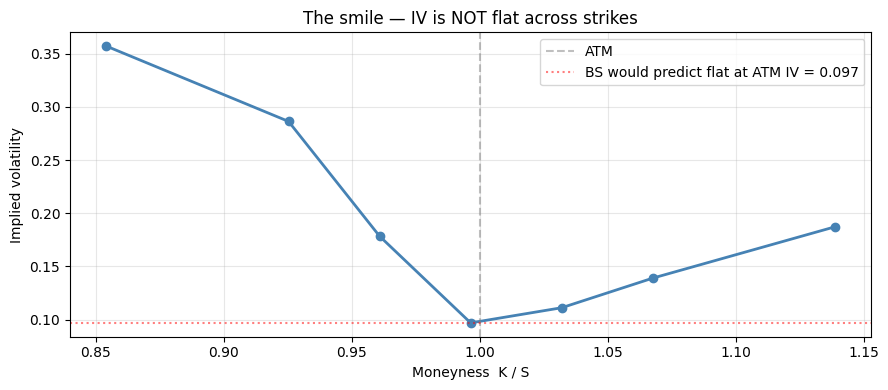


Reading the chart: far-OTM puts (low strikes) carry HIGHER IV than ATM. That gap is
the market's crash-insurance premium. BS would predict a flat horizontal line.
The fact that it isn't flat is what made models like Heston and SABR necessary.


In [9]:
# Suppose the market quotes our K=280, 30-day call at $4.20.
market_price = 4.20

def implied_vol(price, S, K, T, r):
    f = lambda sig: bs_call(S, K, T, r, sig) - price
    return brentq(f, 1e-4, 5.0)

iv_atm = implied_vol(market_price, S0, K, T, r)
print(f'Market quote for K={K:.0f}, 30d call:  ${market_price:.2f}')
print(f'σ that reproduces it (implied vol): {iv_atm:.4f}   ({iv_atm*100:.2f}%)')
print()

# Made-up but realistic equity smile across multiple strikes.
strikes = [240, 260, 270, 280, 290, 300, 320]
prices  = [42.50, 23.80, 13.50, 4.20, 0.95, 0.30, 0.05]

print('Strike → IV across the chain:')
print(f"{'K':>6}  {'price':>8}  {'IV':>8}")
ivs = []
for K_, p_ in zip(strikes, prices):
    try:
        iv_ = implied_vol(p_, S0, K_, T, r)
        ivs.append(iv_)
        print(f'{K_:>6}  ${p_:>7.2f}   {iv_:>7.4f}')
    except Exception:
        ivs.append(np.nan)
        print(f'{K_:>6}  ${p_:>7.2f}   {"--":>7}')

# Plot the smile
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot([k/S0 for k in strikes], ivs, 'o-', lw=2, color='steelblue')
ax.axvline(1.0, color='gray', ls='--', alpha=0.5, label='ATM')
ax.axhline(iv_atm, color='red', ls=':', alpha=0.5, label=f'BS would predict flat at ATM IV = {iv_atm:.3f}')
ax.set_xlabel('Moneyness  K / S'); ax.set_ylabel('Implied volatility')
ax.set_title('The smile — IV is NOT flat across strikes')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print()
print('Reading the chart: far-OTM puts (low strikes) carry HIGHER IV than ATM. That gap is')
print("the market's crash-insurance premium. BS would predict a flat horizontal line.")
print('The fact that it isn\'t flat is what made models like Heston and SABR necessary.')

### Test yourself — the very last one

**Q:** If Black-Scholes were perfectly correct as a model of how the world works, what would the IV-vs-strike chart look like? What does the actual chart's shape tell you about how the market disagrees with BS?

<details><summary>Reveal answer</summary>

If BS were correct, every strike would have the *same* implied volatility — the chart would be a flat horizontal line. There's only one σ in the model; it doesn't depend on strike.

The actual chart slopes downward (low strikes have higher IV than high strikes). This means the market is willing to pay *more* for downside puts (and equivalent low-strike calls via parity) than BS would say they're worth. Why? Because the market believes:

1. Crashes are more likely than a lognormal distribution allows (fat left tail).
2. Even if probabilities were lognormal, investors are risk-averse and willing to overpay for crash insurance.

Both effects show up as the same picture: an IV smile that BS can't reproduce with any single σ. Models like Heston, SABR, and local vol exist specifically to fit this shape.

This is also why "implied vol" and "realised vol" usually disagree — implied vol embeds a risk premium that realised vol doesn't.

</details>

## What you've actually learned

Reading this notebook end-to-end, you've now rebuilt Black-Scholes from a single trade. To recap:

1. **The question:** how much should you charge for an option, when you don't know what the underlying will do?
2. **The trick:** you don't have to predict — you just have to *manufacture* the payoff via dynamic hedging.
3. **The recipe:** at every moment, hold a fraction of a share equal to the option's delta. Rebalance as price moves.
4. **The result:** the cost of running that recipe — averaged or per-path — is the option's fair price. The BS formula is the closed-form expression for that cost.
5. **Why σ matters but μ doesn't:** the recipe is direction-neutral. It only cares about how much the underlying bounces.
6. **What the formula pieces mean:** `N(d1)` = today's hedge ratio. `N(d2)` = probability of exercise (in the risk-neutral world).
7. **Implied vol:** in real life you observe option prices and back out σ. The "smile" is the pattern of how that σ changes with strike — and the fact it isn't flat is what made every later option model necessary.

That's the entire model. Everything else — Greeks, exotics, stochastic vol — is layers built on this foundation.

## Where to go next

Now `01_black_scholes.ipynb` will read very differently. The PDE derivation is just the formal proof of point 4. The risk-neutral expectation is the formal proof of point 6. Girsanov is the bookkeeping that connects the physical and risk-neutral measures.

- For the formal derivations (PDE, risk-neutral expectation, Girsanov) → `01_black_scholes.ipynb`.
- For Greeks (delta, gamma, vega, theta as sensitivities) → `03_greeks.ipynb`.
- For options without closed forms (Asians, barriers, Americans) → `04_binomial_trees.ipynb`, `05_monte_carlo_pricing.ipynb`.
- For when BS breaks (the smile, in detail) → `06_implied_vol_surface.ipynb`, `07_heston.ipynb`.